<a href="https://colab.research.google.com/github/mireillebishay/machine-learning-practice/blob/titanic/Titanic_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap

Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import shap

Load and Show the Dataset

In [ ]:
# load the dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# tuple
print(f"Shape of the DataFrame: {df.shape}")
# number of columns
print(f"Number of columns: {df.shape[1]}")
# number of rows
print(f"Number of rows: {df.shape[0]}")
# column names
print("Column names:")
for col in df.columns:
    print(col)
# basic statistics
print("\nData types of columns:")
print(df.dtypes)
print("\nBasic statistics for numerical columns:")
print(df.describe())
print("\nBasic statistics for all columns:")
print(df.describe(include='all'))
# summary
print("\nSummary of the DataFrame:")
print(df.info())

Shape of the DataFrame: (891, 12)
Number of columns: 12
Number of rows: 891
Column names:
PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked

Data types of columns:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Basic statistics for numerical columns:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000 

Clean the Dataset

In [ ]:
# replace missing ages with median Age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# fill missing Embarked values with mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# drop the Cabin column
df.drop('Cabin', axis=1, inplace=True)

# verify the result
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
None


Create Two New Columns

In [ ]:
# FamilySize = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# IsAlone = 1 if FamilySize == 1 else 0
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

# verify the result
print(df[['FamilySize', 'IsAlone']].head())
print("\nSummary of the DataFrame:")
print(df.info())

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1

Summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  FamilySize   891 non-null    int64  
 12  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 90.6+ KB
None


Numerical Summaries

In [ ]:
print("\nHow many survived:")
print(df['Survived'].value_counts())

print("\nSurvival rate (percentage):")
print(df['Survived'].mean())

print("\nSurvival rate by sex:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by passenger class:")
print(df.groupby('Pclass')['Survived'].mean())

print("\nAverage age of survivors vs non-survivors:")
print(df.groupby('Survived')['Age'].mean())

print("\nDoes being alone affect survival?")
print(df.groupby('IsAlone')['Survived'].mean())



How many survived:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate (percentage):
0.3838383838383838

Survival rate by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Average age of survivors vs non-survivors:
Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

Does being alone affect survival?
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Visualizations

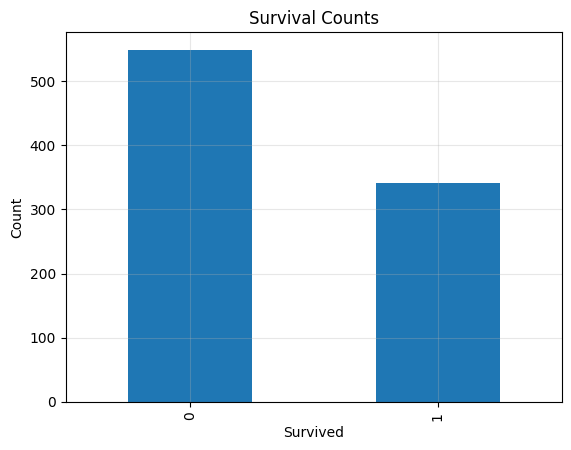

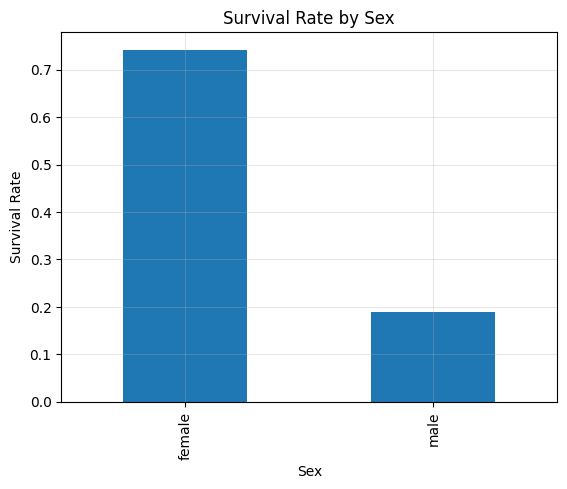

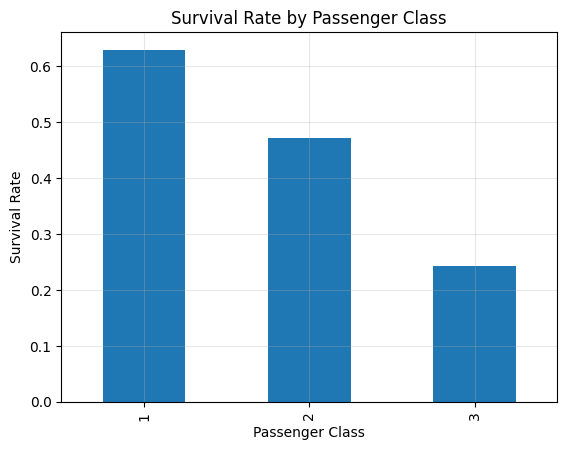

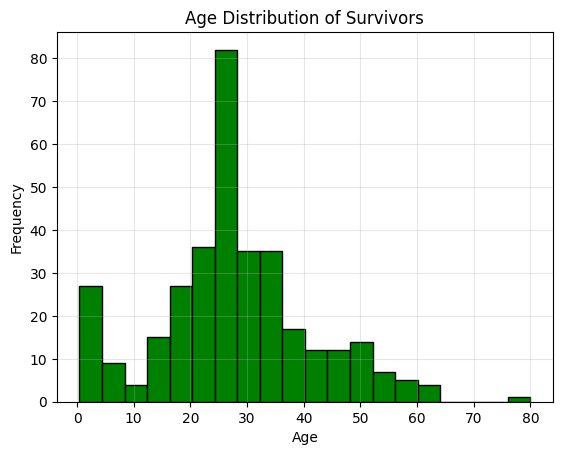

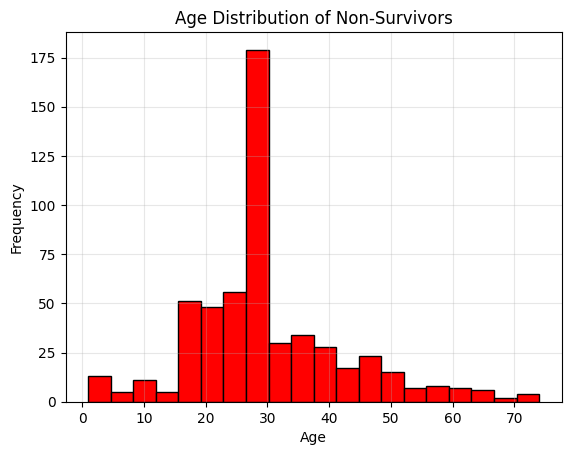

In [ ]:
# 1. bar chart of survival counts
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Counts')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

# 2. bar chart of survival rate by sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.grid(alpha=0.3)
plt.show()

# 3. bar chart of survival rate by passenger class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.grid(alpha=0.3)
plt.show()

# 4. histogram of age for survivors
df[df['Survived'] == 1]['Age'].plot(kind='hist', bins=20, edgecolor='black', color='green')
plt.title('Age Distribution of Survivors')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

# 5. histogram of age for non-survivors
df[df['Survived'] == 0]['Age'].plot(kind='hist', bins=20, edgecolor='black', color='red')
plt.title('Age Distribution of Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

Logistic Regression Model for Predicting Passenger Survival Using Key Demographic and Travel Features

In [ ]:
# convert Sex from text to binary
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# train-test split
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize
numeric_features = ['Age', 'Fare', 'FamilySize']
scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# train logistic regression
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)

# evaluate
accuracy = accuracy_score(y_test, y_pred.round())
classification_rep = classification_report(y_test, y_pred.round())
confusion_mat = confusion_matrix(y_test, y_pred.round())
probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

# print results
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", classification_rep)
print("Confusion Matrix:\n", confusion_mat)
print("ROC-AUC:", auc)

Accuracy: 0.8044692737430168
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
 [[91 14]
 [21 53]]
ROC-AUC: 0.8774774774774776


Interpret Logistic Regression Coefficients

      Feature  Coefficient
0      Pclass    -0.873312
1         Sex     2.568230
2         Age    -0.387727
3        Fare     0.161272
4  FamilySize    -0.645501
5     IsAlone    -0.674722


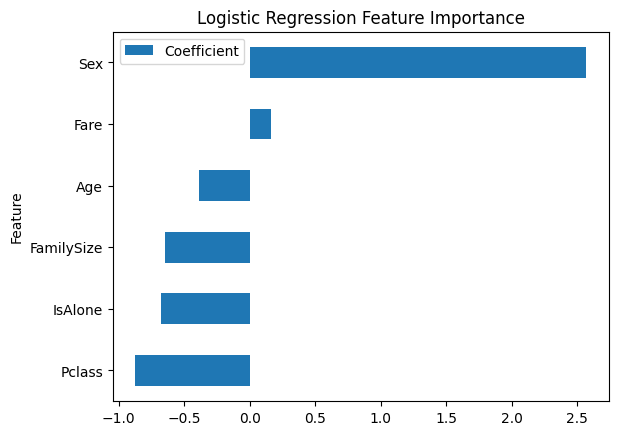

In [ ]:
# get coefficients and feature names
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_[0]})
print(coef_df)

# visualization
coef_df.sort_values(by='Coefficient').plot(
    x='Feature',
    y='Coefficient',
    kind='barh',
    title='Logistic Regression Feature Importance'
)
plt.show()

Train a Random Forest Model

In [ ]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

# predict on test set
y_pred_rf = model_rf.predict(X_test)

# get probabilities for the positive class (survived)
y_probs_rf = model_rf.predict_proba(X_test)[:, 1]

# evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
classification_rep_rf = classification_report(y_test, y_pred_rf)
confusion_mat_rf = confusion_matrix(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)

# print results
print(f"Random Forest Accuracy: {accuracy_rf}")
print("Random Forest Classification Report:\n", classification_rep_rf)
print("Random Forest Confusion Matrix:\n", confusion_mat_rf)
print("Random Forest ROC-AUC:", auc_rf)

Random Forest Accuracy: 0.8044692737430168
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179

Random Forest Confusion Matrix:
 [[89 16]
 [19 55]]
Random Forest ROC-AUC: 0.8954954954954956


Feature Importance (Random Forest)

      Feature  Importance
3        Fare    0.305776
1         Sex    0.271723
2         Age    0.263654
0      Pclass    0.083068
4  FamilySize    0.063179
5     IsAlone    0.012601


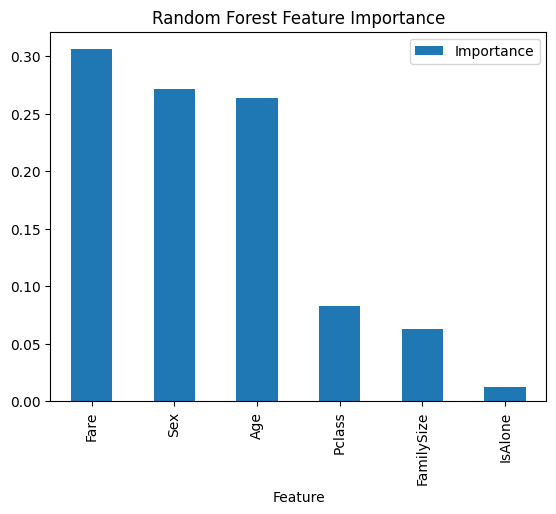

In [ ]:
feat_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_importances)

# visualization
feat_importances.plot(x='Feature', y='Importance', kind='bar', title='Random Forest Feature Importance')
plt.show()


Hyperparameter Tuning & Model Optimization for Random Forest

In [ ]:
# create a hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# run the grid search
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC-AUC Score: 0.8578650793140934


Evaluate Tuned Random Forest on Test Set

In [ ]:
y_best_pred = best_rf.predict(X_test)
y_best_probs = best_rf.predict_proba(X_test)[:, 1]

accuracy_best = accuracy_score(y_test, y_best_pred)
classification_rep_best = classification_report(y_test, y_best_pred)
confusion_mat_best = confusion_matrix(y_test, y_best_pred)
auc_best = roc_auc_score(y_test, y_best_probs)

print(f"Tuned Random Forest Accuracy: {accuracy_best}")
print("Tuned Random Forest Classification Report:\n", classification_rep_best)
print("Tuned Random Forest Confusion Matrix:\n", confusion_mat_best)
print("Tuned Random Forest ROC-AUC:", auc_best)

Tuned Random Forest Accuracy: 0.8324022346368715
Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.83      0.74      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Tuned Random Forest Confusion Matrix:
 [[94 11]
 [19 55]]
Tuned Random Forest ROC-AUC: 0.8989060489060489


Hyperparameter Tuning & Model Optimization for Logistic Regression

In [ ]:
# create a hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# set up GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# run the grid search
grid_search_lr.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search_lr.best_params_)
print("Best ROC-AUC Score:", grid_search_lr.best_score_)

best_lr = grid_search_lr.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC-AUC Score: 0.84554407405266


Evaluate Tuned Logistic Regression on Test Set

In [ ]:
y_best_pred_lr = best_lr.predict(X_test)
y_best_probs_lr = best_lr.predict_proba(X_test)[:, 1]

accuracy_best_lr = accuracy_score(y_test, y_best_pred_lr)
classification_rep_best_lr = classification_report(y_test, y_best_pred_lr)
confusion_mat_best_lr = confusion_matrix(y_test, y_best_pred_lr)
auc_best_lr = roc_auc_score(y_test, y_best_probs_lr)

print(f"Tuned Logistic Regression Accuracy: {accuracy_best_lr}")
print("Tuned Logistic Regression Classification Report:\n", classification_rep_best_lr)
print("Tuned Logistic Regression Confusion Matrix:\n", confusion_mat_best_lr)
print("Tuned Logistic Regression ROC-AUC:", auc_best_lr)

Tuned Logistic Regression Accuracy: 0.7988826815642458
Tuned Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Tuned Logistic Regression Confusion Matrix:
 [[91 14]
 [22 52]]
Tuned Logistic Regression ROC-AUC: 0.8772200772200772


# Starting from Scratch (New Pipeline, Boosting, SHAP)

Train-Test Split on Data

In [ ]:
new_df = pd.read_csv(url)
new_df = new_df.dropna(subset=['Embarked'])

features = ['Pclass', 'Sex', 'Embarked', 'Age', 'Fare', 'SibSp', 'Parch']
target = 'Survived'

X_new = new_df[features]
y_new = new_df[target]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

Preprocessing & Pipeline

In [ ]:
numeric_features_new = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features_new = ['Pclass', 'Sex', 'Embarked']

# remove NaN
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# build a ColumnTransformer
preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_new),
        ('cat', categorical_transformer, categorical_features_new)
    ]
)

# plug it into a Pipeline with GradientBoosting
gb_model = GradientBoostingClassifier(random_state=42)

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_new),
    ('classifier', gb_model)
])

# train the pipeline
gb_pipeline.fit(X_train_new, y_train_new)

# evaluate it
y_pred_gb = gb_pipeline.predict(X_test_new)
y_probs_gb = gb_pipeline.predict_proba(X_test_new)[:, 1]
accuracy_gb = accuracy_score(y_test_new, y_pred_gb)
classification_rep_gb = classification_report(y_test_new, y_pred_gb)
confusion_mat_gb = confusion_matrix(y_test_new, y_pred_gb)
auc_gb = roc_auc_score(y_test_new, y_probs_gb)

print(f"Gradient Boosting Accuracy: {accuracy_gb}")
print("Gradient Boosting Classification Report:\n", classification_rep_gb)
print("Gradient Boosting Confusion Matrix:\n", confusion_mat_gb)
print("Gradient Boosting ROC-AUC:", auc_gb)

Gradient Boosting Accuracy: 0.8314606741573034
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.77        68

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178

Gradient Boosting Confusion Matrix:
 [[97 13]
 [17 51]]
Gradient Boosting ROC-AUC: 0.8566176470588237


SHAP Values

SHAP values for passenger index 15
       Feature  SHAP value
8     Sex_male    1.018537
7   Sex_female    0.898012
11  Embarked_S    0.548925
1         Fare    0.309683
0          Age    0.146887
2        SibSp    0.050642
9   Embarked_C    0.021887
3        Parch    0.009928
5     Pclass_2   -0.000272
10  Embarked_Q   -0.071690
4     Pclass_1   -0.081707
6     Pclass_3   -0.647414


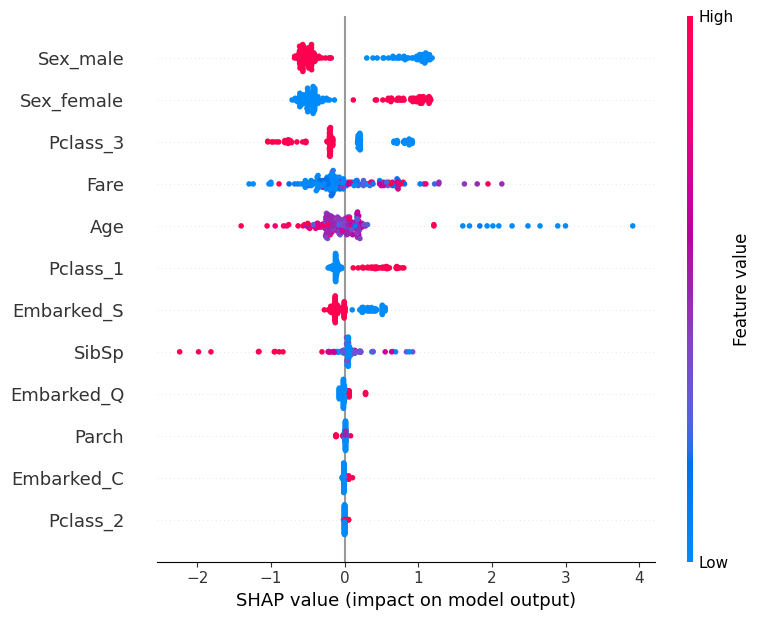

In [ ]:
shap.initjs()

# take apart the pipeline:
preprocessor = gb_pipeline.named_steps['preprocessor']
gb_model_trained = gb_pipeline.named_steps['classifier']

# transform the test set with the same preprocessor used during training
X_test_transformed = preprocessor.transform(X_test_new)

# get the feature names after preprocessing
numeric_feature_names = numeric_features_new  # ['Age', 'Fare', 'SibSp', 'Parch']

# get the cat transformer from the ColumnTransformer
cat_transformer = preprocessor.named_transformers_['cat']
ohe = cat_transformer.named_steps['onehot']

# OneHotEncoder creates new column names like 'Sex_female', 'Sex_male', 'Embarked_C', ...
cat_feature_names = list(ohe.get_feature_names_out(categorical_features_new))

# final feature name list in the same order as X_test_transformed
all_feature_names = numeric_feature_names + cat_feature_names

# build a SHAP explainer for the tree model
explainer = shap.TreeExplainer(gb_model_trained)

# compute SHAP values for the transformed test data
shap_values = explainer.shap_values(X_test_transformed)

# look at one example passenger
i = 15
x_example = X_test_transformed[i]
shap_values_example = shap_values[i]

# put the SHAP values for this passenger into a table
shap_df = pd.DataFrame({
    'Feature': all_feature_names,
    'SHAP value': shap_values_example
}).sort_values(by='SHAP value', ascending=False)

print("SHAP values for passenger index", i)
print(shap_df.head(15))

# which features matter most overall?
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)
